In [52]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

RANDOM_STATE = 56

X, y = load_iris(return_X_y=True)
mask = y != 2
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, y_train, X_test, y_test = (
    X_train.T,
    y_train.reshape(1, -1),
    X_test.T,
    y_test.reshape(1, -1)
    )

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(4, 80) (1, 80) (4, 20) (1, 20)


In [53]:
def sigmoid(X):
    return 1 / (1 + np.exp(-X))

In [72]:
X[:, 0]

array([6. , 5.4, 5. , 6.3, 4.8, 5. , 6.6, 5.1, 4.6, 5.1, 5. , 5.3, 7. ,
       5.9, 6.8, 6.1, 5.9, 5.5, 5.1, 4.4, 6.6, 6. , 4.6, 5.5, 5.5, 4.9,
       5.7, 5.8, 6.1, 5. , 6. , 5. , 6.4, 5.8, 6.2, 5. , 5.7, 5.1, 6.3,
       6.7, 5.7, 5.5, 4.8, 6.5, 4.7, 4.4, 5.2, 5.1, 5.4, 4.3, 5.4, 6.7,
       5.6, 4.5, 5.6, 5.1, 5.4, 5.1, 5.7, 4.9, 5.2, 5.4, 5.4, 5.5, 5.5,
       4.8, 5. , 5.6, 4.8, 4.8, 5.7, 5.5, 4.9, 4.6, 6.3, 5.8, 4.9, 5.6,
       5.7, 6. ])

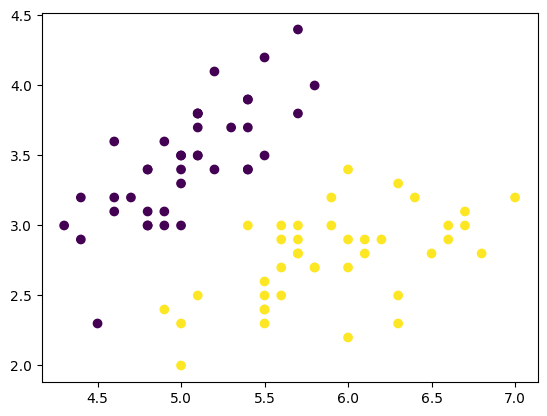

In [69]:
X = X_train.T  # (m, 4)
y = y_train.ravel()

plt.scatter(
    X[:, 0],   # feature 1
    X[:, 1],   # feature 2
    c=y
)
plt.show()

In [50]:
class perceptron_network:

    def __init__(self, lr, max_iter):
        self.lr = lr
        self.max_iter = max_iter

    def forward(self, X):
        self.z1 = self.weights @ X + self.bias
        self.a1 = sigmoid(self.z1)

        return self
    
    def backward(self, X, y):

        dz1 = self.a1 - y
        dw = dz1 @ X.T
        db = np.sum(dz1)

        self.weights -= self.lr * dw
        self.bias -= self.lr * db

    def fit(self, X, y):
        
        n_features = X.shape[0]
        self.weights = np.random.randn(1, n_features)
        self.bias = np.random.randn()

        for epoch in range(self.max_iter):
            self.forward(X)
            self.backward(X, y)

            if (epoch % 10 == 0) and (epoch != 0):
                y_hat = (self.a1 > 0.5).astype(int).reshape(-1,)
                print(f"epoch: {epoch}, model f1 in train: {f1_score(y.reshape(-1,), y_hat)}")

    def predict(self, X):
        return (self.forward(X).a1 > 0.5).astype(int)

In [70]:
phrum_teron = perceptron_network(0.03, 50)
phrum_teron.fit(X_train, y_train)
print(y_test)
print(phrum_teron.predict(X_test))

epoch: 10, model f1 in train: 1.0
epoch: 20, model f1 in train: 1.0
epoch: 30, model f1 in train: 1.0
epoch: 40, model f1 in train: 1.0
[[1 1 0 1 1 0 1 0 1 0 0 0 1 0 1 1 0 1 0 0]]
[[1 1 0 1 1 0 1 0 1 0 0 0 1 0 1 1 0 1 0 0]]
